In [62]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
from sklearn.metrics import precision_recall_curve, auc, roc_curve

In [3]:
# Replace this path with your Kaggle dataset path
DATA_PATH = "/kaggle/input/datasets/alisrafilniloy/rd-accident/Modified_Accident_Dataset final.xlsx"

df_raw = pd.read_excel(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (47680, 31)


,Accident Serial No,Date,Time,Location,Longitude and Latitude,Driver Age,Accident Narrative,Vehicle Info,Vehicle Count,Death Count,Death Info,Injury Count,Injury Info,Light Condition,Weather_x,Road Surface Type,Road nature,Road classification,Place characteristic,Type of Road connection point,Road Surface Condition,Victim Category,Trafic Condition,ID,Year,Month,Accident_Intensity,Junction,Traffic_Control,Weather_y,Lighting
0,377,2022-06-05 00:00:00,06.35 am,Dhaka Regional Airport road (near the City Gat...,23.84278° N/90.40056° E,26,"At around 11:45 AM, a fully loaded cargo truck...",Car - Pedestrian collision,2,0,"Mr. Saiful Islam 50 years old, resident of Sa...",0,"Mr. Saiful Islam 50 years old, resident of Sa...",Dusk,Rainy,Paved,Lane,City Road,Urban,T-Junction,Dry,Pedestrian,Police determined,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
1,378,2022-03-06 00:00:00,08:20 AM,Mirpur-11 Road near Pallabi Bridge,23.80610° N/90.36690° E,26,A motorcycle collided with a bicycle due to su...,Motorcycle-bicycle collision,2,2,"Mr. Saiful Islam 50 years old, resident of Sa...",0,Motorcyclist: minor head injuries; Cyclist: mi...,Day,Sunny,Paved,Lane,City Road,Urban,T-Junction,Wet,Motorcyclist,Speeding,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
2,379,2022-12-02 00:00:00,07:30 AM,Old Airport Road near Uttara Sector-6,23.86500° N/90.40000° E,26,"A car collided with a scooter at the junction,...",Car-scooter collision,2,0,"Mr. Saiful Islam 50 years old, resident of Sa...",0,Scooter rider: broken arm,Night,Foggy,Paved,Lane,City Road,Urban,T-Junction,Wet,Scooter rider,Right-of-way violation,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
3,380,13/6/2022,02:15 PM,Mirpur DOHS Road near BNS Center,23.81200° N/90.36500° E,26,A motorcycle collided with a speeding car; the...,Motorcycle - Car collision,2,0,"Mr. Saiful Islam 50 years old, resident of Sa...",1,Rider: critical head trauma,Dusk,Sunny,Paved,Lane,Regional Road,Urban,T-Junction,Dry,Motorcyclist,Speeding,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
4,381,14/6/2022,09:00 PM,Banani Circle-2 Intersection,23.78700° N/90.41700° E,26,A pedestrian was struck while crossing at a ma...,Vehicle - Pedestrian collision,1,1,"Mr. Saiful Islam 50 years old, resident of Sa...",3,Pedestrian: leg fractures,Night,Sunny,Paved,Lane,City Road,Urban,T-Junction,Good,Pedestrian,Distraction,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk


In [4]:
print("Columns:")
print(df_raw.columns.tolist())

print("\nMissing values:")
print(df_raw.isnull().sum().sort_values(ascending=False).head(30))

Columns:
['Accident Serial No', 'Date ', 'Time', 'Location', 'Longitude and Latitude', 'Driver  Age ', 'Accident Narrative', 'Vehicle Info', 'Vehicle Count ', 'Death Count', 'Death Info', 'Injury Count', 'Injury Info', 'Light Condition', 'Weather_x', 'Road Surface Type', 'Road nature', 'Road classification', 'Place characteristic', 'Type of Road connection point ', 'Road Surface Condition', 'Victim Category', 'Trafic Condition ', 'ID', 'Year', 'Month', 'Accident_Intensity', 'Junction', 'Traffic_Control', 'Weather_y', 'Lighting']

Missing values:
Accident Serial No                0
Date                              0
Time                              0
Location                          0
Longitude and Latitude            0
Driver  Age                       0
Accident Narrative                0
Vehicle Info                      0
Vehicle Count                     0
Death Count                       0
Death Info                        0
Injury Count                      0
Injury Info     

In [5]:
df = df_raw.copy()

# Clean column names
df.columns = [c.strip().replace("  ", " ").replace(" ", "_") for c in df.columns]

print(df.columns.tolist())

['Accident_Serial_No', 'Date', 'Time', 'Location', 'Longitude_and_Latitude', 'Driver_Age', 'Accident_Narrative', 'Vehicle_Info', 'Vehicle_Count', 'Death_Count', 'Death_Info', 'Injury_Count', 'Injury_Info', 'Light_Condition', 'Weather_x', 'Road_Surface_Type', 'Road_nature', 'Road_classification', 'Place_characteristic', 'Type_of_Road_connection_point', 'Road_Surface_Condition', 'Victim_Category', 'Trafic_Condition', 'ID', 'Year', 'Month', 'Accident_Intensity', 'Junction', 'Traffic_Control', 'Weather_y', 'Lighting']


In [6]:
# Parse Date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Robust Time parsing
def parse_time(value):
    if pd.isna(value):
        return pd.NaT
    
    s = str(value).strip().lower()
    s = s.replace(".", ":")
    s = re.sub(r"\s+", " ", s)
    
    formats = ["%I:%M %p", "%I:%M%p", "%H:%M"]
    for fmt in formats:
        try:
            return pd.to_datetime(s, format=fmt)
        except:
            continue
    
    try:
        return pd.to_datetime(s)
    except:
        return pd.NaT

parsed_time = df["Time"].apply(parse_time)

df["hour"] = parsed_time.dt.hour
df["day_of_week"] = df["Date"].dt.day_name()
df["month_num"] = df["Date"].dt.month
df["year_from_date"] = df["Date"].dt.year

df[["Date", "Time", "hour", "day_of_week", "month_num", "year_from_date"]].head()

,Date,Time,hour,day_of_week,month_num,year_from_date
0,2022-06-05,06.35 am,6,Sunday,6.0,2022.0
1,2022-03-06,08:20 AM,8,Sunday,3.0,2022.0
2,2022-12-02,07:30 AM,7,Friday,12.0,2022.0
3,2022-06-13,02:15 PM,14,Monday,6.0,2022.0
4,2022-06-14,09:00 PM,21,Tuesday,6.0,2022.0


In [7]:
# Extract latitude and longitude from "Longitude_and_Latitude"

def extract_lat_lon(text):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan])
    
    s = str(text)
    nums = re.findall(r"[-+]?\d+\.\d+", s)
    
    if len(nums) >= 2:
        return pd.Series([float(nums[0]), float(nums[1])])
    else:
        return pd.Series([np.nan, np.nan])

df[["latitude", "longitude"]] = df["Longitude_and_Latitude"].apply(extract_lat_lon)

df[["Longitude_and_Latitude", "latitude", "longitude"]].head()

,Longitude_and_Latitude,latitude,longitude
0,23.84278° N/90.40056° E,23.84278,90.40056
1,23.80610° N/90.36690° E,23.80610,90.36690
2,23.86500° N/90.40000° E,23.86500,90.40000
3,23.81200° N/90.36500° E,23.81200,90.36500
4,23.78700° N/90.41700° E,23.78700,90.41700


In [8]:
# Clean text columns
text_cols = [
    "Location", "Vehicle_Info", "Light_Condition", "Weather_x", "Weather_y",
    "Road_Surface_Type", "Road_nature", "Road_classification",
    "Place_characteristic", "Type_of_Road_connection_point",
    "Road_Surface_Condition", "Victim_Category", "Trafic_Condition",
    "Accident_Intensity", "Junction", "Traffic_Control", "Lighting"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan, "": np.nan})

# Weather cleanup
df["weather_final"] = df["Weather_y"]
df["weather_final"] = df["weather_final"].fillna(df["Weather_x"])
df["weather_final"] = df["weather_final"].replace({
    "Clear": "Sunny",
    "clear": "Sunny",
    "Rain": "Rainy",
    "rain": "Rainy",
    "Fog": "Foggy",
    "fog": "Foggy"
})

# Lighting cleanup
df["lighting_final"] = df["Lighting"]
df["lighting_final"] = df["lighting_final"].fillna(df["Light_Condition"])

print("Weather categories:")
print(df["weather_final"].value_counts(dropna=False).head(20))

print("\nLighting categories:")
print(df["lighting_final"].value_counts(dropna=False).head(20))

Weather categories:
weather_final
Rainy       18750
Sunny       17001
Foggy        7449
Overcast     4480
Name: count, dtype: int64

Lighting categories:
lighting_final
Day      22896
Night    12919
Dusk      9395
Dawn      2470
Name: count, dtype: int64


In [9]:
# Time-of-day feature
def time_of_day(hour):
    if pd.isna(hour):
        return "Unknown"
    h = int(hour)
    if 5 <= h < 8:
        return "Early Morning"
    elif 8 <= h < 12:
        return "Morning"
    elif 12 <= h < 17:
        return "Afternoon"
    elif 17 <= h < 21:
        return "Evening"
    else:
        return "Night"

df["time_of_day"] = df["hour"].apply(time_of_day)

# Weekend feature
df["is_weekend"] = df["day_of_week"].isin(["Friday", "Saturday"]).astype(int)

# Vehicle group feature
def vehicle_group(text):
    s = str(text).lower()
    
    if "motorcycle" in s or "bike" in s:
        return "Motorcycle"
    elif "bus" in s:
        return "Bus"
    elif "truck" in s or "lorry" in s:
        return "Truck"
    elif "car" in s or "microbus" in s or "jeep" in s or "taxi" in s:
        return "Car"
    elif "rickshaw" in s:
        return "Rickshaw"
    elif "pickup" in s or "van" in s or "covered van" in s:
        return "Pickup/Van"
    elif "scooter" in s:
        return "Scooter"
    elif "pedestrian" in s:
        return "Pedestrian Involved"
    else:
        return "Other"

df["vehicle_group"] = df["Vehicle_Info"].apply(vehicle_group)

df[["Vehicle_Info", "vehicle_group", "hour", "time_of_day", "is_weekend"]].head(10)

,Vehicle_Info,vehicle_group,hour,time_of_day,is_weekend
0,Car - Pedestrian collision,Car,6,Early Morning,0
1,Motorcycle-bicycle collision,Motorcycle,8,Morning,0
2,Car-scooter collision,Car,7,Early Morning,1
3,Motorcycle - Car collision,Motorcycle,14,Afternoon,0
4,Vehicle - Pedestrian collision,Pedestrian Involved,21,Night,0
5,Bicycle-autorickshaw collision,Rickshaw,18,Evening,0
6,Car-parked vehicle collision,Car,11,Morning,0
7,Car-taxi collision,Car,6,Early Morning,0
8,Rickshaw-motorcycle collision,Motorcycle,9,Morning,1
9,Mini-bus accident,Bus,23,Night,1


In [10]:
# Severity score at accident level
# This is the core of your title: "Based on Severity Analysis"

for col in ["Death_Count", "Injury_Count", "Vehicle_Count", "Driver_Age"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["Death_Count"] = df["Death_Count"].fillna(0)
df["Injury_Count"] = df["Injury_Count"].fillna(0)

# Severity score formula
df["severity_score"] = (
    5 * df["Death_Count"] +
    2 * df["Injury_Count"] +
    1
)

df[["Death_Count", "Injury_Count", "severity_score"]].head()

,Death_Count,Injury_Count,severity_score
0,0,0,1
1,2,0,11
2,0,0,1
3,0,1,3
4,1,3,12


count    47680.000000
mean         9.993918
std          4.962795
min          1.000000
25%          6.000000
50%         10.000000
75%         14.000000
max         19.000000
Name: severity_score, dtype: float64


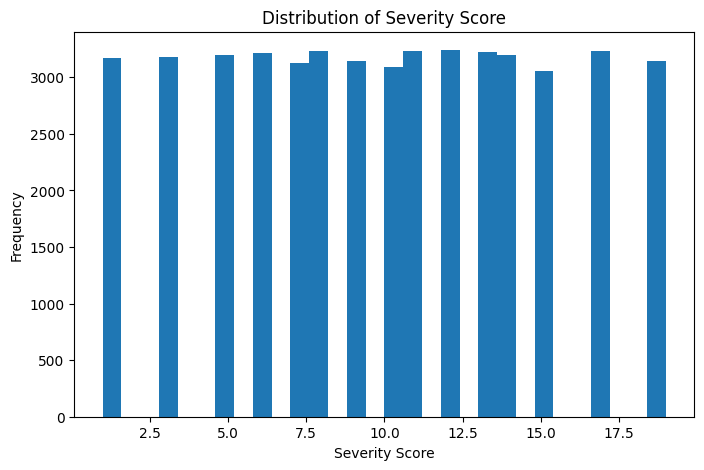

In [11]:
# Analytical EDA 1: severity distribution

print(df["severity_score"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["severity_score"], bins=30)
plt.title("Distribution of Severity Score")
plt.xlabel("Severity Score")
plt.ylabel("Frequency")
plt.show()

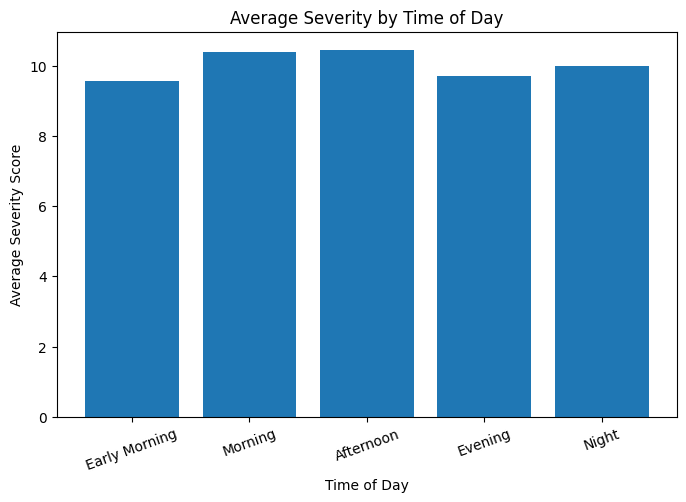

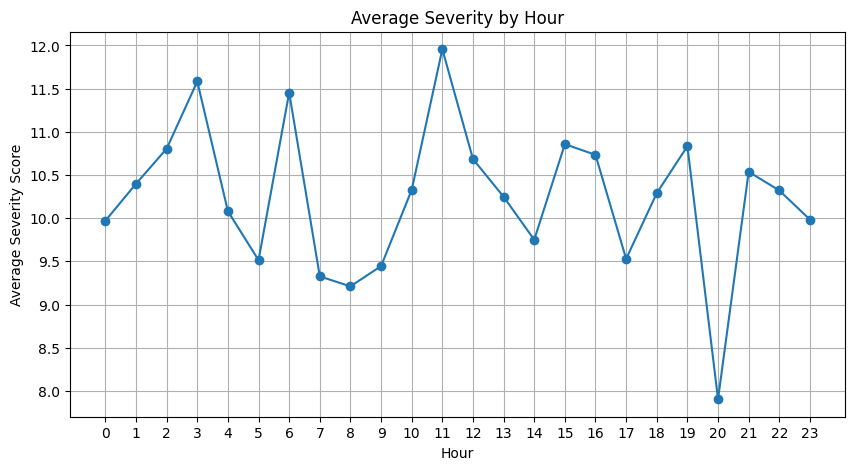

In [12]:
# Analytical EDA 2: average severity by time of day

severity_tod = df.groupby("time_of_day")["severity_score"].mean().reindex(
    ["Early Morning", "Morning", "Afternoon", "Evening", "Night", "Unknown"]
)

plt.figure(figsize=(8, 5))
plt.bar(severity_tod.index, severity_tod.values)
plt.title("Average Severity by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Severity Score")
plt.xticks(rotation=20)
plt.show()

severity_hour = df.groupby("hour")["severity_score"].mean()

plt.figure(figsize=(10, 5))
plt.plot(severity_hour.index, severity_hour.values, marker="o")
plt.title("Average Severity by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Severity Score")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

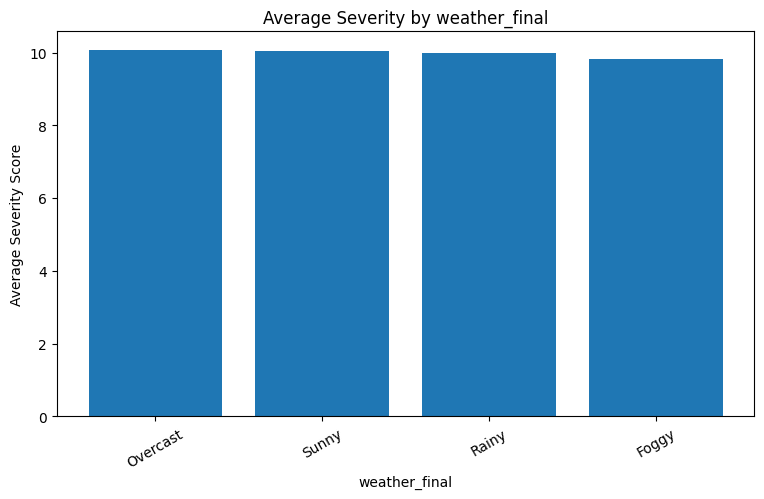

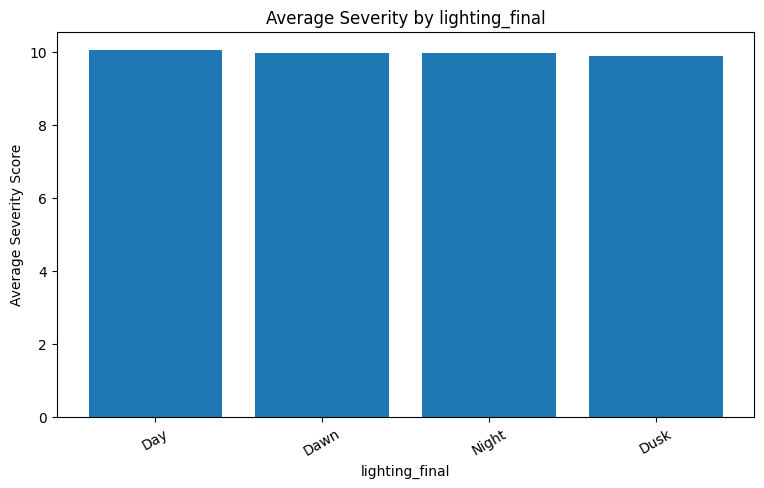

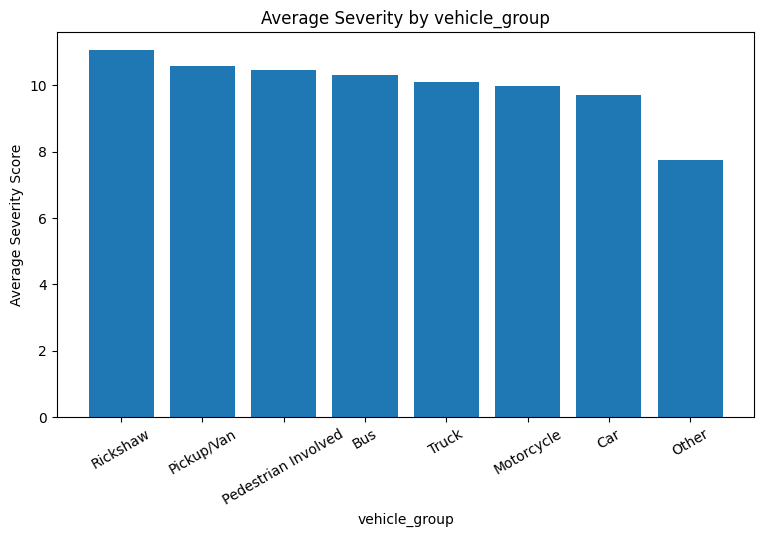

In [13]:
# Analytical EDA 3: average severity by weather, lighting, vehicle type

for col in ["weather_final", "lighting_final", "vehicle_group"]:
    temp = df.groupby(col)["severity_score"].mean().sort_values(ascending=False).head(15)
    plt.figure(figsize=(9, 5))
    plt.bar(temp.index.astype(str), temp.values)
    plt.title(f"Average Severity by {col}")
    plt.xlabel(col)
    plt.ylabel("Average Severity Score")
    plt.xticks(rotation=30)
    plt.show()

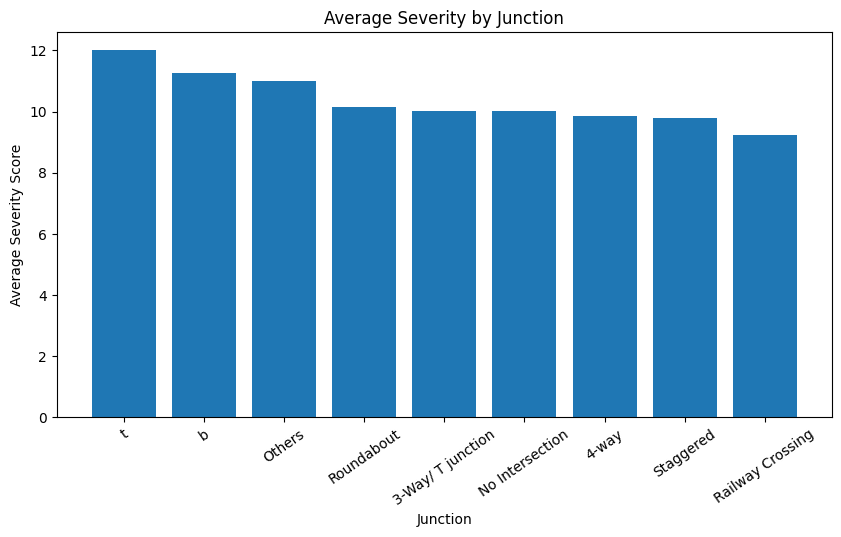

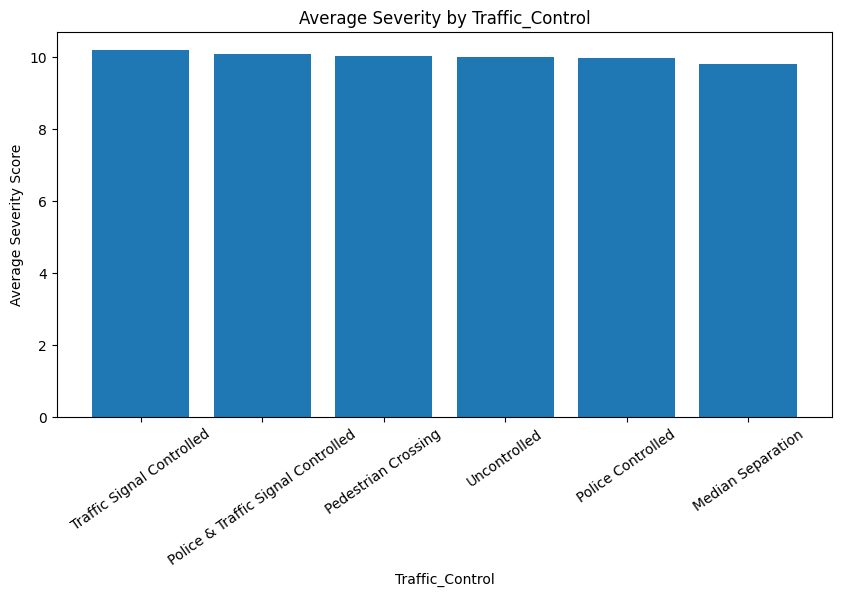

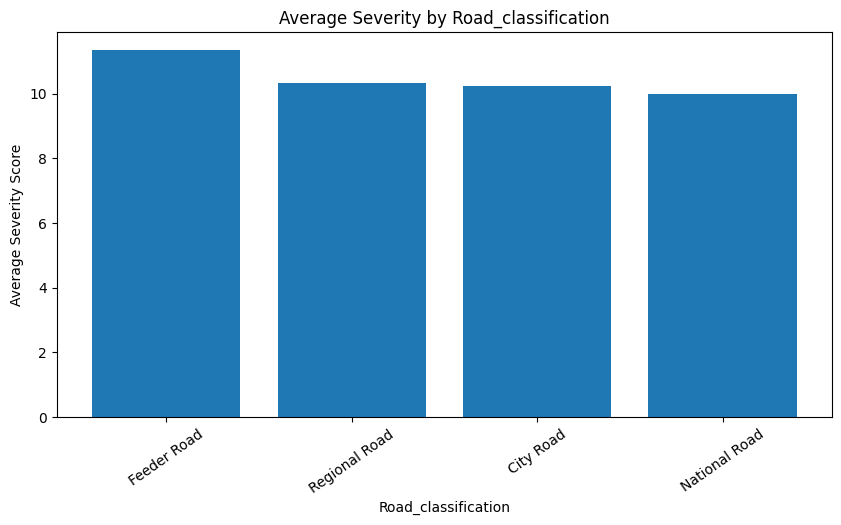

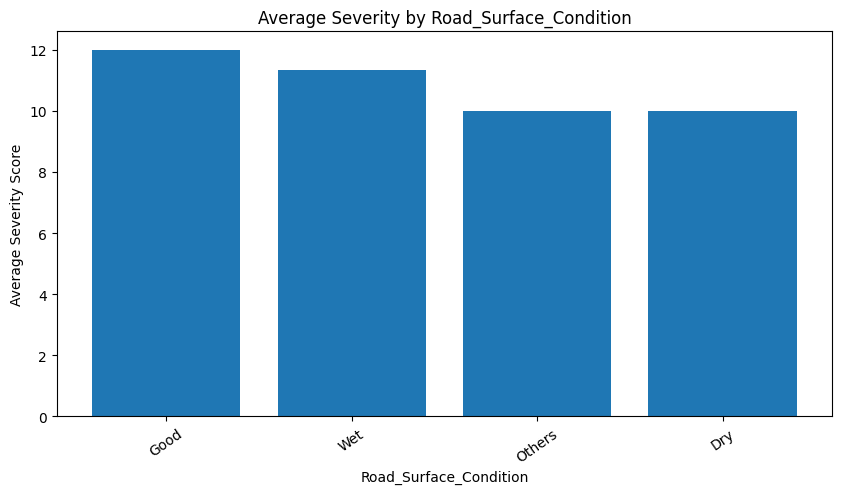

In [71]:
# Analytical EDA 4: average severity by road environment

for col in ["Junction", "Traffic_Control", "Road_classification", "Road_Surface_Condition"]:
    temp = df.groupby(col)["severity_score"].mean().sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 5))
    plt.bar(temp.index.astype(str), temp.values)
    plt.title(f"Average Severity by {col}")
    plt.xlabel(col)
    plt.ylabel("Average Severity Score")
    plt.xticks(rotation=35)
    plt.show()

In [15]:
# Create location-level dataset
# This is the correct level for hotspot identification

location_df = (
    df.groupby("Location", dropna=False)
      .agg(
          accident_count=("Accident_Serial_No", "count"),
          total_deaths=("Death_Count", "sum"),
          total_injuries=("Injury_Count", "sum"),
          avg_severity=("severity_score", "mean"),
          total_severity=("severity_score", "sum"),
          avg_driver_age=("Driver_Age", "mean"),
          avg_vehicle_count=("Vehicle_Count", "mean"),
          avg_hour=("hour", "mean"),
          avg_latitude=("latitude", "mean"),
          avg_longitude=("longitude", "mean"),
          dominant_weather=("weather_final", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_lighting=("lighting_final", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_day=("day_of_week", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_time_of_day=("time_of_day", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_vehicle_group=("vehicle_group", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_road_surface=("Road_Surface_Type", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_road_nature=("Road_nature", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_road_class=("Road_classification", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_place_characteristic=("Place_characteristic", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_connection_point=("Type_of_Road_connection_point", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_surface_condition=("Road_Surface_Condition", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_victim_category=("Victim_Category", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_traffic_condition=("Trafic_Condition", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_junction=("Junction", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          dominant_traffic_control=("Traffic_Control", lambda x: x.mode().iloc[0] if x.mode().shape[0] > 0 else "Unknown"),
          weekend_ratio=("is_weekend", "mean")
      )
      .reset_index()
)

print("Location-level dataset shape:", location_df.shape)
location_df.head()

Location-level dataset shape: (2250, 27)


,Location,accident_count,total_deaths,total_injuries,avg_severity,total_severity,avg_driver_age,avg_vehicle_count,avg_hour,avg_latitude,avg_longitude,dominant_weather,dominant_lighting,dominant_day,dominant_time_of_day,dominant_vehicle_group,dominant_road_surface,dominant_road_nature,dominant_road_class,dominant_place_characteristic,dominant_connection_point,dominant_surface_condition,dominant_victim_category,dominant_traffic_condition,dominant_junction,dominant_traffic_control,weekend_ratio
0,"1, West Hazir Para, DIT Road",10,9,21,9.700000,97,24.0,2.0,23.0,23.83113,90.42431,Sunny,Night,Wednesday,Night,Motorcycle,Paved,Lane,National Road,Urban,Others,Dry,Motorcyclist,Others,No Intersection,Uncontrolled,0.0
1,10 circle to Bijoy Nagar,36,33,62,9.027778,325,24.0,2.0,23.0,23.83113,90.42431,Rainy,Day,Wednesday,Night,Motorcycle,Paved,Lane,National Road,Urban,Others,Dry,Motorcyclist,Others,3-Way/ T junction,Police Controlled,0.0
2,"10 to Bijoy Sarani, Rokeya Sarani",62,57,124,9.596774,595,24.0,2.0,23.0,23.83113,90.42431,Rainy,Day,Wednesday,Night,Motorcycle,Paved,Lane,National Road,Urban,Others,Dry,Motorcyclist,Others,3-Way/ T junction,Police Controlled,0.0
3,10 to Kochukhet,11,8,13,7.000000,77,24.0,2.0,23.0,23.83113,90.42431,Sunny,Night,Wednesday,Night,Motorcycle,Paved,Lane,National Road,Urban,Others,Dry,Motorcyclist,Others,No Intersection,Police Controlled,0.0
4,"100 Feet, Vatara Thana",1,0,0,1.000000,1,35.0,2.0,8.0,23.79200,90.42600,Rainy,Day,Wednesday,Morning,Other,Paved,Lane,City Road,Urban,Crossroads,Dry,Bicyclist,Uncontrolled,No Intersection,Uncontrolled,0.0


In [16]:
# Severity-based hotspot definition
# Hotspot = location in top 10% of total severity

hotspot_threshold = location_df["total_severity"].quantile(0.90)
location_df["hotspot_label"] = (location_df["total_severity"] >= hotspot_threshold).astype(int)

print("Hotspot threshold:", hotspot_threshold)
print("\nHotspot distribution:")
print(location_df["hotspot_label"].value_counts())
print("\nHotspot proportion:")
print(location_df["hotspot_label"].value_counts(normalize=True).round(4))

Hotspot threshold: 441.0

Hotspot distribution:
hotspot_label
0    2024
1     226
Name: count, dtype: int64

Hotspot proportion:
hotspot_label
0    0.8996
1    0.1004
Name: proportion, dtype: float64


In [17]:
# Top severity-based hotspots
top_locations = location_df.sort_values("total_severity", ascending=False).head(15)
top_locations[["Location", "accident_count", "total_deaths", "total_injuries", "avg_severity", "total_severity", "hotspot_label"]]

,Location,accident_count,total_deaths,total_injuries,avg_severity,total_severity,hotspot_label
540,Dhaka-Mymensing Highway,627,674,1271,10.429027,6539,1
1675,"Rainbow Crossing, in front of Square Electroni...",355,375,756,10.540845,3742,1
1333,Mirpur Road,328,302,665,9.658537,3168,1
338,Beribadh Road,285,259,580,9.614035,2740,1
1085,Kazi Nazrul Islam Avenue,267,270,553,10.198502,2723,1
999,"Kakoli Crossing, Airport Road",262,275,511,10.148855,2659,1
122,"Airport Circle, Dhaka-Mymensing Highway",260,266,526,10.161538,2642,1
541,Dhaka-Mymensing Road,217,221,432,10.073733,2186,1
130,Airport Road,202,215,404,10.321782,2085,1
1382,"Mohakhali Flyover, Airport Road",213,199,421,9.624413,2050,1


In [18]:
# EDA on hotspot locations vs non-hotspot locations

hotspot_summary = location_df.groupby("hotspot_label")[[
    "accident_count", "total_deaths", "total_injuries", "avg_severity", "total_severity"
]].mean()

hotspot_summary

,accident_count,total_deaths,total_injuries,avg_severity,total_severity
hotspot_label,,,,,
0,14.334486,14.279644,28.490119,10.077434,142.712945
1,82.597345,83.362832,165.469027,10.102327,830.349558


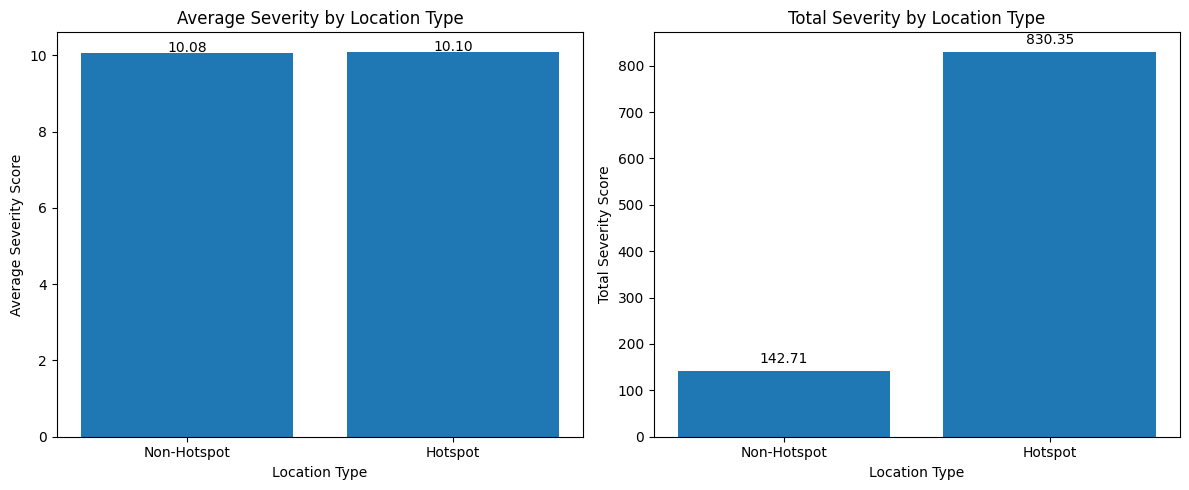

In [68]:
plot_df = hotspot_summary.reset_index().copy()
plot_df["hotspot_label"] = plot_df["hotspot_label"].map({0: "Non-Hotspot", 1: "Hotspot"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(plot_df["hotspot_label"], plot_df["avg_severity"])
axes[0].set_title("Average Severity by Location Type")
axes[0].set_xlabel("Location Type")
axes[0].set_ylabel("Average Severity Score")

for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}", ha="center")

bars2 = axes[1].bar(plot_df["hotspot_label"], plot_df["total_severity"])
axes[1].set_title("Total Severity by Location Type")
axes[1].set_xlabel("Location Type")
axes[1].set_ylabel("Total Severity Score")

for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + (plot_df["total_severity"].max() * 0.02), f"{h:.2f}", ha="center")

plt.tight_layout()
plt.show()

In [28]:
# Prepare modeling dataset
# IMPORTANT:
# We do NOT use Location directly
# We do NOT use total_severity directly
# We do NOT use avg_severity directly
# We do NOT use total_deaths / total_injuries directly
# We do NOT use accident_count directly
# because hotspot is defined from severity concentration at location level

feature_cols = [
    "avg_driver_age",
    "avg_vehicle_count",
    "avg_hour",
    "avg_latitude",
    "avg_longitude",
    "dominant_weather",
    "dominant_lighting",
    "dominant_day",
    "dominant_time_of_day",
    "dominant_vehicle_group",
    "dominant_road_surface",
    "dominant_road_nature",
    "dominant_road_class",
    "dominant_place_characteristic",
    "dominant_connection_point",
    "dominant_surface_condition",
    "dominant_victim_category",
    "dominant_traffic_condition",
    "dominant_junction",
    "dominant_traffic_control",
    "weekend_ratio"
]

target_col = "hotspot_label"

model_df = location_df[feature_cols + [target_col]].copy()

numeric_cols = [
    "avg_driver_age",
    "avg_vehicle_count",
    "avg_hour",
    "avg_latitude",
    "avg_longitude",
    "weekend_ratio"
]

categorical_cols = [c for c in feature_cols if c not in numeric_cols]

for col in numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

for col in categorical_cols:
    model_df[col] = model_df[col].fillna("Unknown").astype(str)

print("Model dataset shape:", model_df.shape)
model_df.head()

Model dataset shape: (2250, 22)


,avg_driver_age,avg_vehicle_count,avg_hour,avg_latitude,avg_longitude,dominant_weather,dominant_lighting,dominant_day,dominant_time_of_day,dominant_vehicle_group,dominant_road_surface,dominant_road_nature,dominant_road_class,dominant_place_characteristic,dominant_connection_point,dominant_surface_condition,dominant_victim_category,dominant_traffic_condition,dominant_junction,dominant_traffic_control,weekend_ratio,hotspot_label
0,24.0,2.0,23.0,23.83113,90.42431,Sunny,Night,Wednesday,Night,Motorcycle,Paved,Lane,National Road,Urban,Others,Dry,Motorcyclist,Others,No Intersection,Uncontrolled,0.0,0
1,24.0,2.0,23.0,23.83113,90.42431,Rainy,Day,Wednesday,Night,Motorcycle,Paved,Lane,National Road,Urban,Others,Dry,Motorcyclist,Others,3-Way/ T junction,Police Controlled,0.0,0
2,24.0,2.0,23.0,23.83113,90.42431,Rainy,Day,Wednesday,Night,Motorcycle,Paved,Lane,National Road,Urban,Others,Dry,Motorcyclist,Others,3-Way/ T junction,Police Controlled,0.0,1
3,24.0,2.0,23.0,23.83113,90.42431,Sunny,Night,Wednesday,Night,Motorcycle,Paved,Lane,National Road,Urban,Others,Dry,Motorcyclist,Others,No Intersection,Police Controlled,0.0,0
4,35.0,2.0,8.0,23.79200,90.42600,Rainy,Day,Wednesday,Morning,Other,Paved,Lane,City Road,Urban,Crossroads,Dry,Bicyclist,Uncontrolled,No Intersection,Uncontrolled,0.0,0


In [31]:
X = model_df[feature_cols].copy()
y = model_df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Total locations:", len(location_df))
print("Train locations:", len(X_train))
print("Test locations:", len(X_test))

Total locations: 2250
Train locations: 1800
Test locations: 450


In [36]:
# Threshold tuning helper for imbalanced hotspot classification
def find_best_threshold(y_true, y_prob, model_name="Model"):
    thresholds = np.arange(0.20, 0.71, 0.05)
    rows = []

    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        p = precision_score(y_true, pred, zero_division=0)
        r = recall_score(y_true, pred, zero_division=0)
        f = f1_score(y_true, pred, zero_division=0)
        rows.append([t, p, r, f])

    threshold_df = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1"])
    best_idx = threshold_df["f1"].idxmax()
    best_threshold = threshold_df.loc[best_idx, "threshold"]

    print(f"\nBest threshold for {model_name}: {best_threshold:.2f}")
    print(threshold_df)

    return best_threshold, threshold_df


# Preprocessor for Random Forest and XGBoost
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_cols
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
            ]),
            categorical_cols
        )
    ]
)

def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan

    print(f"\n===== {model_name} =====")
    print(f"Test locations used in confusion matrix: {len(y_true)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}" if not np.isnan(auc) else "ROC-AUC  : N/A")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"{model_name} - Confusion Matrix (Counts)")

    ConfusionMatrixDisplay(confusion_matrix=cm_norm).plot(ax=axes[1], colorbar=False)
    axes[1].set_title(f"{model_name} - Confusion Matrix (Normalized)")

    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc
    }

results = []


===== Random Forest =====
Test locations used in confusion matrix: 450
Accuracy : 0.6667
Precision: 0.1613
Recall   : 0.5556
F1-score : 0.2500
ROC-AUC  : 0.6578

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.68      0.79       405
           1       0.16      0.56      0.25        45

    accuracy                           0.67       450
   macro avg       0.55      0.62      0.52       450
weighted avg       0.86      0.67      0.73       450



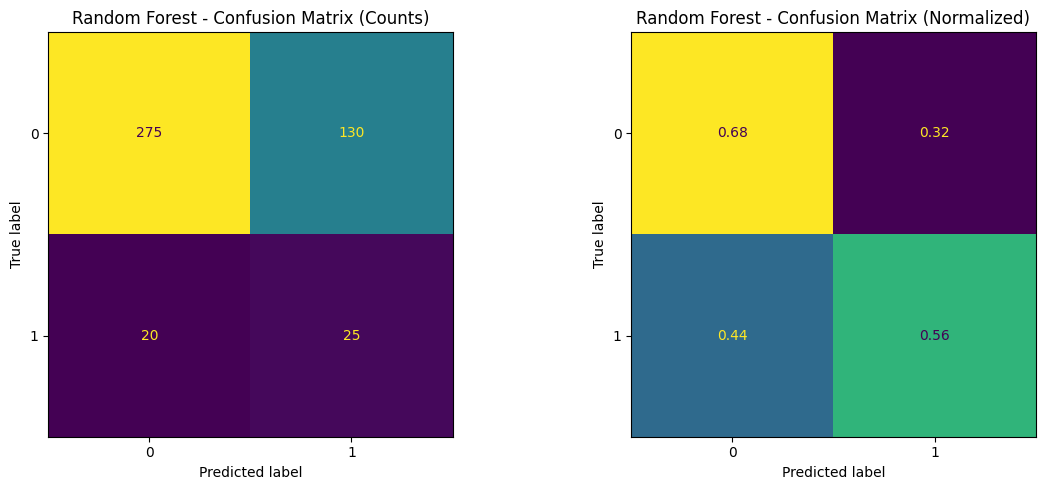

In [50]:
# Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_result = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
results.append(rf_result)


Best threshold for XGBoost: 0.65
    threshold  precision    recall        f1
0        0.20   0.124601  0.866667  0.217877
1        0.25   0.131206  0.822222  0.226300
2        0.30   0.134545  0.822222  0.231250
3        0.35   0.137546  0.822222  0.235669
4        0.40   0.144033  0.777778  0.243056
5        0.45   0.142857  0.755556  0.240283
6        0.50   0.155000  0.688889  0.253061
7        0.55   0.164474  0.555556  0.253807
8        0.60   0.165563  0.555556  0.255102
9        0.65   0.190083  0.511111  0.277108
10       0.70   0.111111  0.022222  0.037037

===== XGBoost =====
Test locations used in confusion matrix: 450
Accuracy : 0.7333
Precision: 0.1901
Recall   : 0.5111
F1-score : 0.2771
ROC-AUC  : 0.6741

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84       405
           1       0.19      0.51      0.28        45

    accuracy                           0.73       450
   macro avg       0.56     

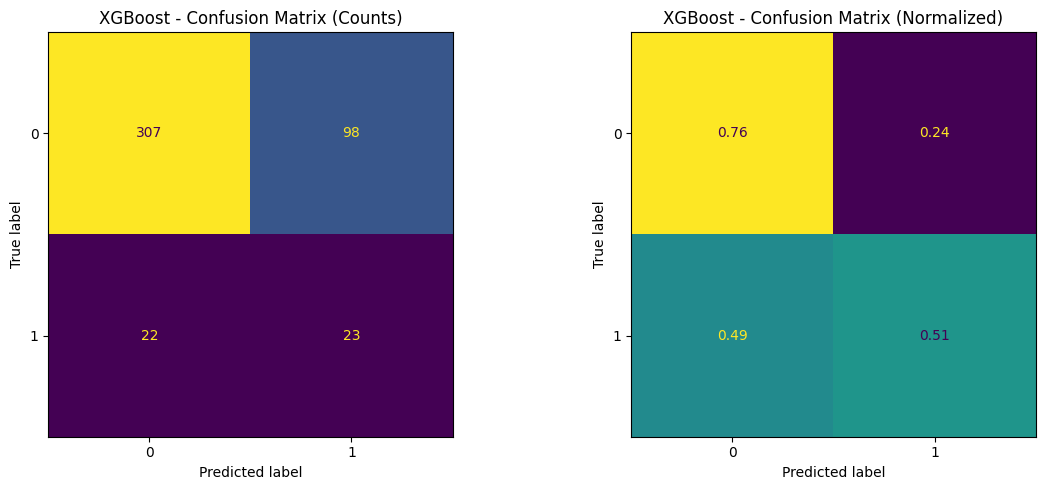

In [49]:
# XGBoost with imbalance handling
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight_value,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

best_xgb_threshold, xgb_threshold_table = find_best_threshold(y_test, xgb_prob, "XGBoost")

xgb_pred = (xgb_prob >= best_xgb_threshold).astype(int)

xgb_result = evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)
results.append(xgb_result)


Best threshold for CatBoost: 0.55
    threshold  precision    recall        f1
0        0.20   0.123457  0.888889  0.216802
1        0.25   0.123333  0.822222  0.214493
2        0.30   0.128920  0.822222  0.222892
3        0.35   0.145228  0.777778  0.244755
4        0.40   0.147679  0.777778  0.248227
5        0.45   0.145455  0.711111  0.241509
6        0.50   0.160000  0.622222  0.254545
7        0.55   0.169014  0.533333  0.256684
8        0.60   0.169014  0.533333  0.256684
9        0.65   0.161290  0.222222  0.186916
10       0.70   0.000000  0.000000  0.000000

===== CatBoost =====
Test locations used in confusion matrix: 450
Accuracy : 0.6911
Precision: 0.1690
Recall   : 0.5333
F1-score : 0.2567
ROC-AUC  : 0.6706

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.71      0.81       405
           1       0.17      0.53      0.26        45

    accuracy                           0.69       450
   macro avg       0.55   

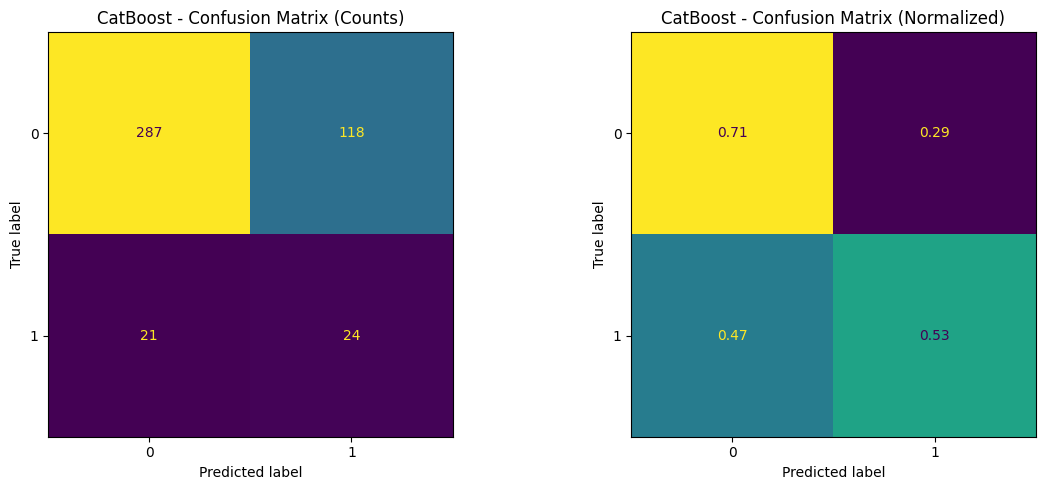

In [48]:
# CatBoost with imbalance handling
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in numeric_cols:
    median_value = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(median_value)
    X_test_cb[col] = X_test_cb[col].fillna(median_value)

for col in categorical_cols:
    X_train_cb[col] = X_train_cb[col].fillna("Unknown").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("Unknown").astype(str)

cat_model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0
)

cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_cols
)

cat_prob = cat_model.predict_proba(X_test_cb)[:, 1]

best_cat_threshold, cat_threshold_table = find_best_threshold(y_test, cat_prob, "CatBoost")

cat_pred = (cat_prob >= best_cat_threshold).astype(int)

cat_result = evaluate_model("CatBoost", y_test, cat_pred, cat_prob)
results.append(cat_result)


Best threshold for Hybrid Ensemble: 0.65
    threshold  precision    recall        f1
0        0.20   0.121875  0.866667  0.213699
1        0.25   0.128289  0.866667  0.223496
2        0.30   0.141732  0.800000  0.240803
3        0.35   0.144033  0.777778  0.243056
4        0.40   0.147679  0.777778  0.248227
5        0.45   0.148936  0.777778  0.250000
6        0.50   0.150538  0.622222  0.242424
7        0.55   0.170068  0.555556  0.260417
8        0.60   0.170068  0.555556  0.260417
9        0.65   0.196429  0.488889  0.280255
10       0.70   0.000000  0.000000  0.000000

===== Hybrid Ensemble =====
Test locations used in confusion matrix: 450
Accuracy : 0.7489
Precision: 0.1964
Recall   : 0.4889
F1-score : 0.2803
ROC-AUC  : 0.6710

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       405
           1       0.20      0.49      0.28        45

    accuracy                           0.75       450
   macro avg

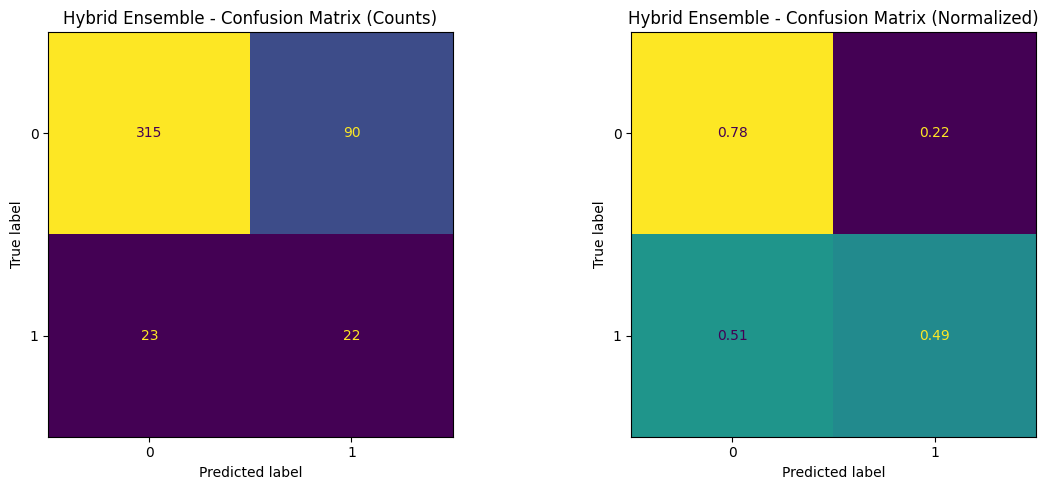

In [59]:
# Hybrid Ensemble Model
# Weighted probability blending of Random Forest + XGBoost + CatBoost

# Random Forest probabilities
rf_prob_h = rf_model.predict_proba(X_test)[:, 1]

# XGBoost probabilities
xgb_prob_h = xgb_model.predict_proba(X_test)[:, 1]

# CatBoost probabilities
cat_prob_h = cat_model.predict_proba(X_test_cb)[:, 1]

# Weighted blend
# You can adjust weights later if needed
hybrid_prob = (0.30 * rf_prob_h) + (0.30 * xgb_prob_h) + (0.40 * cat_prob_h)

# Find best threshold for hybrid model
best_hybrid_threshold, hybrid_threshold_table = find_best_threshold(y_test, hybrid_prob, "Hybrid Ensemble")

# Final hybrid prediction
hybrid_pred = (hybrid_prob >= best_hybrid_threshold).astype(int)

# Evaluate
hybrid_result = evaluate_model("Hybrid Ensemble", y_test, hybrid_pred, hybrid_prob)
results.append(hybrid_result)

In [60]:
results_df = pd.DataFrame(results).drop_duplicates(subset=["Model"], keep="last")
results_df = results_df.sort_values("F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Hybrid Ensemble,0.748889,0.196429,0.488889,0.280255,0.671029
1,XGBoost,0.733333,0.190083,0.511111,0.277108,0.674102
2,CatBoost,0.691111,0.169014,0.533333,0.256684,0.670590
3,Random Forest,0.666667,0.161290,0.555556,0.250000,0.657778
4,Hybrid Ensemble (Accuracy Focused),0.900000,0.000000,0.000000,0.000000,0.683759


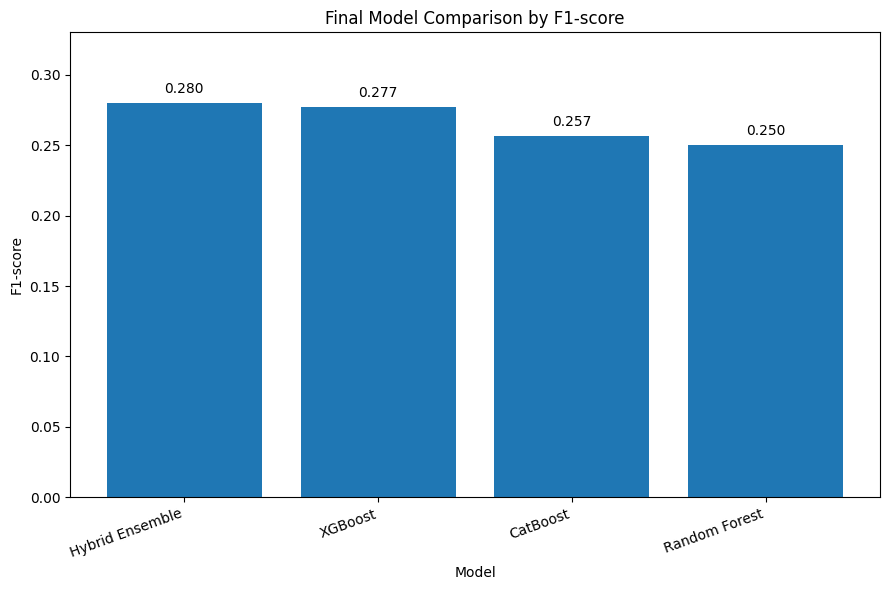

In [61]:
plt.figure(figsize=(9, 6))
bars = plt.bar(results_df_final["Model"], results_df_final["F1"])

plt.title("Final Model Comparison by F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, results_df_final["F1"].max() + 0.05)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

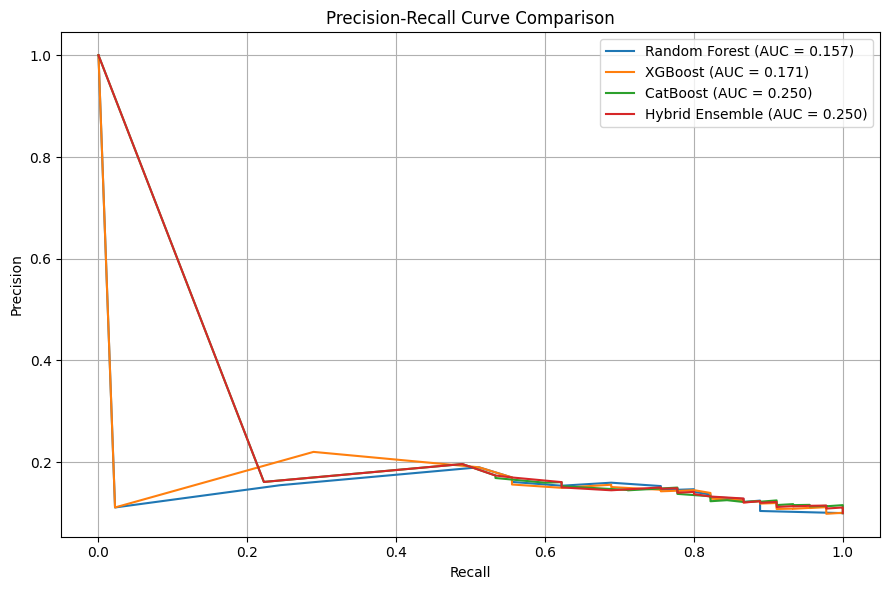

In [64]:
plt.figure(figsize=(9, 6))

for model_name, y_prob in model_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{model_name} (AUC = {pr_auc:.3f})")

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

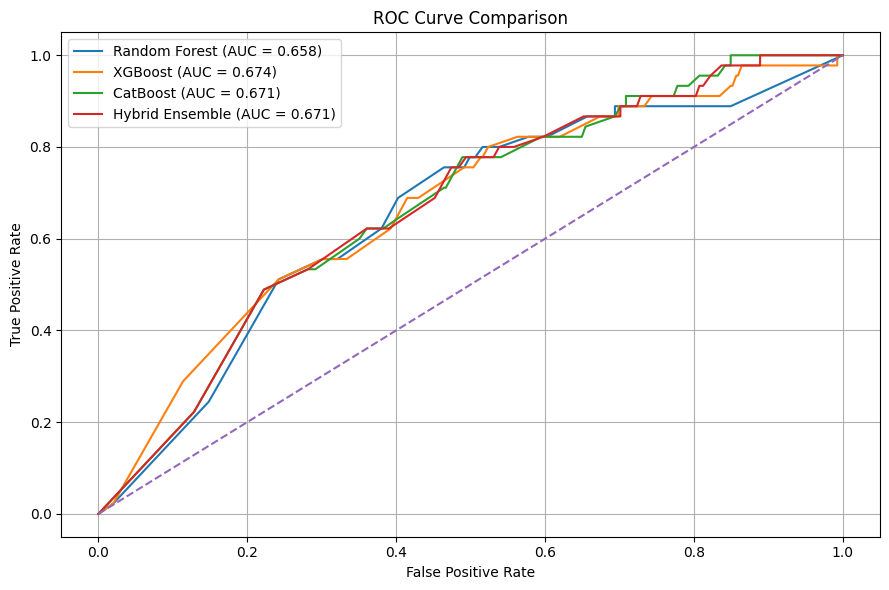

In [65]:
plt.figure(figsize=(9, 6))

for model_name, y_prob in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()